***Importing Libraries***

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

***2. Create DataFreame***

In [12]:
data=pd.read_csv('data6.csv')
df=pd.DataFrame(data)
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


***3. Preprocessing and Stationarity Test***

The first step is to check the stationarity of your data. If the p-value is greater than 0.05.

In [13]:


def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    return result[1]

# Check initial p-value
p_val = check_stationarity(df['Passengers'])

# If p-value > 0.05, apply differencing
if p_val > 0.05:
    print("Data is not stationary. Applying differencing...")
    df['Stationary_Data'] = df['Passengers'].diff().dropna()
    # Check again (you may need a second round of differencing if still > 0.05)
    check_stationarity(df['Stationary_Data'].dropna())

ADF Statistic: 0.8153688792060547
p-value: 0.9918802434376411
Data is not stationary. Applying differencing...
ADF Statistic: -2.829266824170004
p-value: 0.05421329028382491


***4 Identifying Arima Parameters***

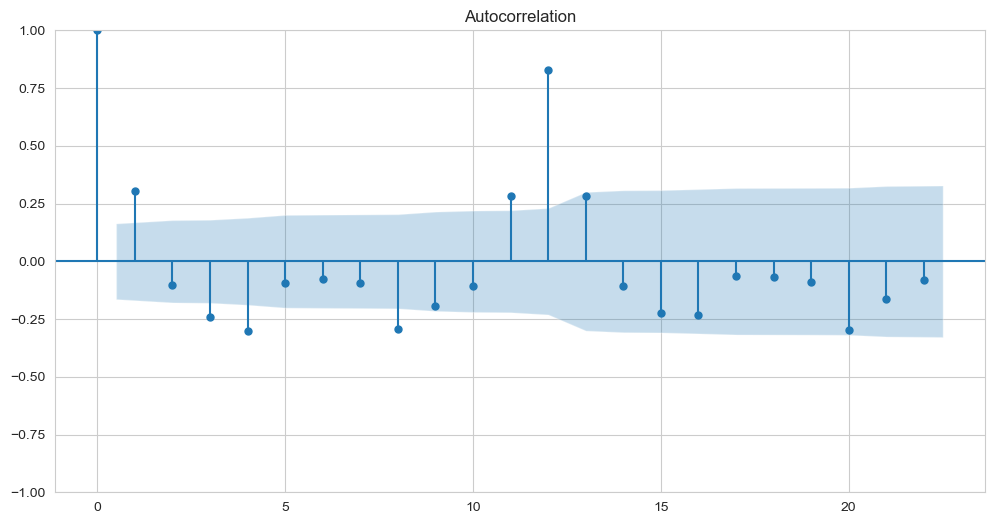

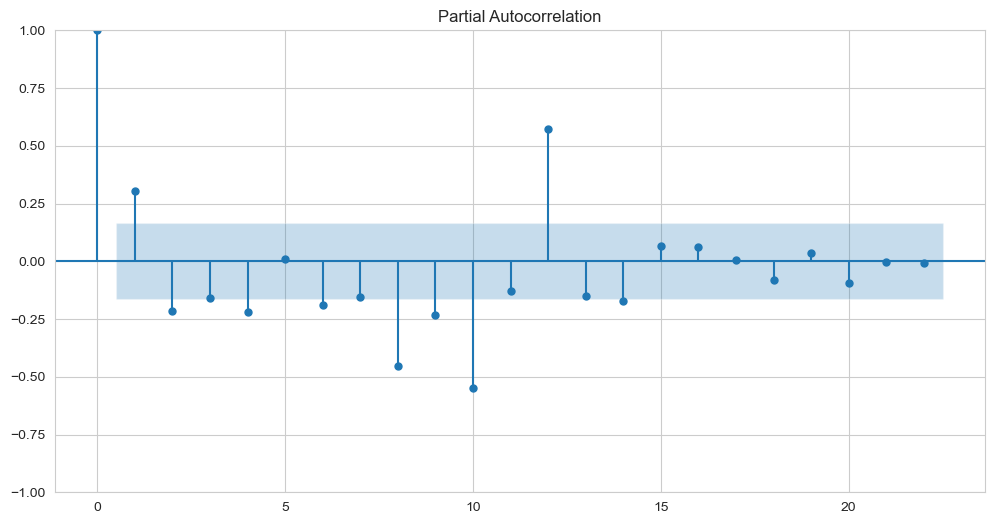

In [14]:

# Use the stationary data for these plots
plot_acf(df['Stationary_Data'].dropna())
plot_pacf(df['Stationary_Data'].dropna())
plt.show()

***Summary for your ARIMA(p, d, q) Model:***

* p (AR): Look at the PACF spikes outside the blue area.
* d (I): This is the number of times you differenced the data to get the p-value below 0.05 (likely $d=1$).
* q (MA): Look at the ACF spikes outside the blue area.

***5. Building Arima Model***

In [15]:
from statsmodels.tsa.arima.model import ARIMA

# Replace p, d, q with the values identified from your plots
# 'd' is the number of times you differenced the data
model = ARIMA(df['Passengers'], order=(1, 1, 1)) 
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=12)
print(forecast)

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Thu, 12 Mar 2026   AIC                           1394.683
Time:                        08:58:20   BIC                           1403.571
Sample:                             0   HQIC                          1398.294
                                - 144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0